In [7]:
import numpy as np
import matplotlib.pyplot as plt
import Comm as com
import math

# Test of the transmission chain #

In [120]:
# Flat fading channel taps
a = 1
tau = 0

# Parameters
B = 100e6
osr = 8
Fs = B * osr
Ts = 1 / Fs
alpha = 0.1

# Channel
span = 80 # Number of symbols
L = span * osr + 1
t_filter = np.linspace(-span/(2*B), span/(2*B), L)
u = com.RRC(t_filter, tau, B, alpha) * a

# Matched filter
u_matched = u

Eu = (1 - alpha/4)
print("Symbol energy (Eu):", Eu)

rc = com.RC(t_filter, tau, B, alpha)
print("RC filter energy:", np.sum(rc**2)*Ts)

Symbol energy (Eu): 0.975
RC filter energy: 9.749999339961014e-09


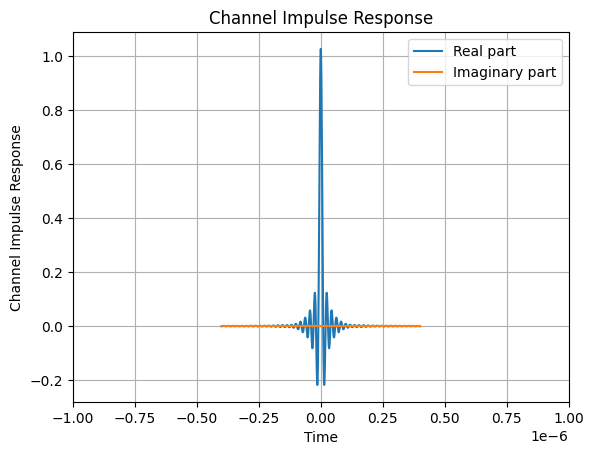

In [82]:
plt.figure()
plt.plot(t_filter, u.real, label='Real part')
plt.plot(t_filter, u.imag, label='Imaginary part')
plt.xlim(-1e-6, 1e-6)
plt.xlabel('Time')
plt.ylabel('Channel Impulse Response')
plt.title('Channel Impulse Response')
plt.grid()
plt.legend()
plt.show()

### Generating random bits ###


In [43]:
def bits_to_qpsk(bits):

    symbols = (2*bits[0::2] - 1) + 1j*(2*bits[1::2] - 1)
    # Normalize the power of the symbols to 1
    symbols /= np.sqrt(2)

    return symbols

def qpsk_to_bits(symbols):

    bits = np.zeros(2*len(symbols), dtype=int)
    bits[0::2] = (np.real(symbols) > 0).astype(int)
    bits[1::2] = (np.imag(symbols) > 0).astype(int)

    return bits



In [44]:
bits = np.random.randint(0, 2, 10)
print("Random bits:", bits)

symbols = bits_to_qpsk(bits)
print("QPSK symbols:", symbols)

bits_estimated = qpsk_to_bits(symbols)
print("Estimated bits:", bits_estimated)

Random bits: [0 1 0 0 1 1 1 0 1 0]
QPSK symbols: [-0.70710678+0.70710678j -0.70710678-0.70710678j  0.70710678+0.70710678j
  0.70710678-0.70710678j  0.70710678-0.70710678j]
Estimated bits: [0 1 0 0 1 1 1 0 1 0]


In [123]:
snr_dB = np.arange(0, 9, 1)
sigma_n_dB = -10*np.log10(1) - snr_dB
print("Noise power (dB):", sigma_n_dB)

bers = np.zeros(len(sigma_n_dB))

for i in range(len(sigma_n_dB)):
    sigma_n = 10**(sigma_n_dB[i]/10) * osr / 2
    for iter in range(100):
        num_bits = 10000
        bits = np.random.randint(0, 2, num_bits)

        # Modulation
        symbols = bits_to_qpsk(bits)
        x = np.zeros(len(symbols)*osr, dtype=complex)
        x[::osr] = symbols

        # Transmission through the channel
        y = np.convolve(x, u, mode='full')

        # Add noise
        noise = np.sqrt(sigma_n) * (np.random.randn(len(y)) + 1j*np.random.randn(len(y)))
        y_noisy = y + noise

        # Matched filtering
        y_matched = np.convolve(y_noisy, u_matched, mode='full') / osr

        # Synchronization (assuming perfect synchronization for simplicity)
        y_sync = y_matched[L-1:L-1+len(symbols)*osr:osr]

        # Demodulation
        bits_estimated = qpsk_to_bits(y_sync)

        # BER calculation
        ber = np.mean(bits != bits_estimated)
        bers[i] += ber

    print(f"SNR: {snr_dB[i]} dB, BER: {bers[i]/100}")

# Average the BERs over the simulations
bers /= 100
print("BERs:", bers)

Noise power (dB): [-0. -1. -2. -3. -4. -5. -6. -7. -8.]
SNR: 0 dB, BER: 0.1588080000000001
SNR: 1 dB, BER: 0.13136199999999995
SNR: 2 dB, BER: 0.10390499999999996
SNR: 3 dB, BER: 0.07926899999999998
SNR: 4 dB, BER: 0.05631700000000001
SNR: 5 dB, BER: 0.037832000000000005
SNR: 6 dB, BER: 0.023125000000000003
SNR: 7 dB, BER: 0.012581999999999992
SNR: 8 dB, BER: 0.005997999999999999
BERs: [0.158808 0.131362 0.103905 0.079269 0.056317 0.037832 0.023125 0.012582
 0.005998]


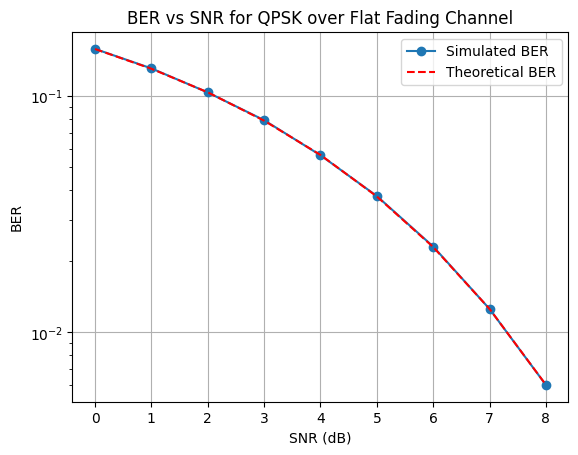

In [124]:
theoretical_ber = np.array([0.5 * math.erfc(np.sqrt(10**(snr_dB[i]/10)/2)) for i in range(len(snr_dB))])

plt.figure()
plt.semilogy(snr_dB, bers, 'o-', label='Simulated BER')
plt.semilogy(snr_dB, theoretical_ber, 'r--', label='Theoretical BER')
plt.xlabel('SNR (dB)')
plt.ylabel('BER')
plt.title('BER vs SNR for QPSK over Flat Fading Channel')
plt.grid()
plt.legend()
plt.show()